# 토트넘 강등 저지 게임 — 당신이 감독이다 (Simple 버전)


In [ ]:
# !pip install SpeechRecognition

In [ ]:
# 라이브러리 임포트 및 API 설정
import os
import json
import random
import tempfile
from dataclasses import dataclass, field

import speech_recognition as sr
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

##### GameState

In [ ]:
# GameState 데이터 클래스 정의
@dataclass
class GameState:
    # 팀 현황
    points: int = 30
    remain_round: int = 7
    position: int = 16
    team_condition: int = 40      # 0~100

    # 게임 흐름
    game_over: bool = False
    ending_type: str = ""         # "survival" | "relegation"
    match_history: list = field(default_factory=list)

    # 일정 (고정)
    schedule: list = field(default_factory=lambda: [
        {"round": 32, "opponent": "Sunderland",  "is_home": False, "strength": 8},
        {"round": 33, "opponent": "Brighton",    "is_home": True,  "strength": 7},
        {"round": 34, "opponent": "Wolves",      "is_home": False, "strength": 7},
        {"round": 35, "opponent": "Aston Villa", "is_home": False, "strength": 8},
        {"round": 36, "opponent": "Leeds",       "is_home": True,  "strength": 6},
        {"round": 37, "opponent": "Chelsea",     "is_home": False, "strength": 9},
        {"round": 38, "opponent": "Everton",     "is_home": True,  "strength": 7},
    ])

    # 경쟁팀 (랜덤 결과로 갱신)
    rival_teams: dict = field(default_factory=lambda: {
        "Nottingham Forest": {"points": 32, "remaining": 7},
        "West Ham":          {"points": 29, "remaining": 7},
        "Leeds United":      {"points": 33, "remaining": 7},
        "Burnley":           {"points": 19, "remaining": 7},
        "Wolves":            {"points": 17, "remaining": 7},
    })

In [ ]:
# 수학적 잔류/강등 확정 여부 계산
def check_relegation_math(gs: GameState) -> dict:
    # 경쟁팀별 최대 가능 승점(현재 + 잔여*3) 내림차순 정렬
    max_pts = sorted(
        [v["points"] + v["remaining"] * 3 for v in gs.rival_teams.values()],
        reverse=True
    )
    safe_line = max_pts[2]  # 18위 예정 팀 기준 (5팀 중 index 2 = 뒤에서 3번째)
    is_safe = gs.points > safe_line
    is_relegated = (gs.points + gs.remain_round * 3) < max_pts[-1]
    return {"is_safe": is_safe, "is_relegated": is_relegated, "safe_line": safe_line}

In [ ]:
# S1 동작 확인
gs = GameState()
print(f"승점: {gs.points}점 | 잔여: {gs.remain_round}경기 | 순위: {gs.position}위 | 컨디션: {gs.team_condition}")
result = check_relegation_math(gs)
print(f"잔류 확정: {result['is_safe']} | 강등 확정: {result['is_relegated']} | 안전선: {result['safe_line']}점")

승점: 37점 | 잔여: 7경기 | 순위: 16위 | 컨디션: 70
잔류 확정: False | 강등 확정: False | 안전선: 50점


##### 경기 승률 계산

In [ ]:
# 경기 승률 계산 (컨디션 + 홈/어웨이 + 상대 강도 반영)
def calculate_win_rate(gs: GameState, match: dict) -> float:
    base = 0.50
    condition_bonus = (gs.team_condition - 50) * 0.003   # 컨디션 50 기준 ±보정
    strength_penalty = (match["strength"] - 5) * 0.04    # 상대 강도 5 기준 ±보정
    home_bonus = 0.05 if match["is_home"] else 0.0
    rate = base + condition_bonus + home_bonus - strength_penalty
    return max(0.10, min(0.90, rate))  # 0.10~0.90 클리핑

##### 경기 시뮬레이션

In [ ]:
# 경기 1경기 시뮬레이션 (gs 직접 수정)
def simulate_match(gs: GameState) -> dict:
    match = gs.schedule[0]  # 다음 경기
    win_rate = calculate_win_rate(gs, match)

    # 승/무/패 가중치: 무·패는 (1-win_rate)를 3:7으로 분배
    draw_rate = (1 - win_rate) * 0.3
    loss_rate = (1 - win_rate) * 0.7
    result = random.choices(["win", "draw", "loss"], weights=[win_rate, draw_rate, loss_rate])[0]

    # 결과별 스코어 (단순 랜덤)
    scores = {"win": ["1-0", "2-0", "2-1", "3-0", "3-1"],
              "draw": ["0-0", "1-1", "2-2"],
              "loss": ["0-1", "0-2", "1-2"]}
    score = random.choice(scores[result])

    # 승점 및 컨디션 업데이트
    pts_delta    = {"win": 3, "draw": 1, "loss": 0}
    cond_delta   = {"win": -5, "draw": -5, "loss": -8}
    gs.points        += pts_delta[result]
    gs.team_condition = max(0, min(100, gs.team_condition + cond_delta[result]))
    gs.remain_round  -= 1
    gs.schedule.pop(0)  # 완료된 경기 제거

    summary = {"result": result, "opponent": match["opponent"], "score": score,
               "round": match["round"], "win_rate": round(win_rate, 2)}
    gs.match_history.append(summary)
    return summary

##### 경쟁팀 랜덤 결과

In [ ]:
# 경쟁팀 결과 랜덤 갱신 (경기마다 1회 호출)
def update_rival_results(gs: GameState) -> dict:
    summary = {}
    for team, data in gs.rival_teams.items():
        if data["remaining"] <= 0:
            continue
        result = random.choices(["win", "draw", "loss"], weights=[50, 30, 20])[0]
        pts = {"win": 3, "draw": 1, "loss": 0}[result]
        data["points"]    += pts
        data["remaining"] -= 1
        summary[team] = {"result": result, "pts_gained": pts, "total": data["points"]}
    return summary

##### 훈련 시뮬레이터

In [ ]:
# 훈련 함수
def apply_training(gs: GameState, recovery: int, fitness: int, tactical: int) -> str:
    assert recovery + fitness + tactical == 100  # 합계 검증

    # 각 항목이 25~42% 범위면 균형 잡힌 훈련으로 판정
    balanced = all(25 <= v <= 42 for v in [recovery, fitness, tactical])

    if balanced:
        delta = random.randint(5, 10)
        gs.team_condition = min(100, gs.team_condition + delta)
        return f"균형 잡힌 훈련 — 컨디션 +{delta} ({gs.team_condition}/100)"
    else:
        delta = random.randint(5, 10)
        gs.team_condition = max(0, gs.team_condition - delta)
        return f"편향된 훈련 — 컨디션 -{delta} ({gs.team_condition}/100)"

In [ ]:
# S2 동작 확인
gs = GameState()

match_result = simulate_match(gs)
print("경기 결과:", match_result)

rival_result = update_rival_results(gs)
print("경쟁팀 결과:", rival_result)

training_msg = apply_training(gs, 34, 33, 33)
print("훈련 결과:", training_msg)

print("현재 상태 - 승점:", gs.points, "/ 컨디션:", gs.team_condition)

경기 결과: {'result': 'loss', 'opponent': 'Sunderland', 'score': '0-1', 'round': 32, 'win_rate': 0.52}
경쟁팀 결과: {'Nottingham Forest': {'result': 'loss', 'pts_gained': 0, 'total': 32}, 'West Ham': {'result': 'win', 'pts_gained': 3, 'total': 32}, 'Leeds United': {'result': 'loss', 'pts_gained': 0, 'total': 33}, 'Burnley': {'result': 'win', 'pts_gained': 3, 'total': 22}, 'Wolves': {'result': 'win', 'pts_gained': 3, 'total': 20}}
훈련 결과: 균형 잡힌 훈련 — 컨디션 +9 (71/100)
현재 상태 - 승점: 37 / 컨디션: 71


##### STT 함수 + 하프타임 스피치

In [ ]:
# 1. 혹시 모를 Xcode 도구 업데이트 (이미 있으면 금방 끝납니다) ㅋ
# !xcode-select --install

# 2. Homebrew로 설치된 portaudio의 정확한 경로를 찾아 변수에 저장합니다.
# !export PORTAUDIO_PATH=$(brew --prefix portaudio)

# 3. 컴파일러 옵션을 직접 주입하며 설치합니다. (이게 가장 확실합니다! ㅋ)
# 1. 환경 변수 설정 (느낌표 없이 입력하세요! ㅋ)
# !export CFLAGS="-I/usr/local/opt/portaudio/include"
# !export LDFLAGS="-L/usr/local/opt/portaudio/lib"

# 2. 설치 진행
# !pip install pyaudio

In [ ]:
# STT: 마이크 입력 → Whisper API → 텍스트 변환
def transcribe_speech(timeout: int = 15) -> str:
    recognizer = sr.Recognizer()
    
    try:
        with sr.Microphone() as source:
            print("주변 소음 측정 중... 잠시만 기다리세요.")
            recognizer.adjust_for_ambient_noise(source, duration=1) # 1초간 소음 측정
            print("말씀하세요... (지금입니다!)")
            
            # phrase_time_limit을 주면 말이 길어져도 끊어서 인식하기 좋음
            audio = recognizer.listen(source, timeout=timeout, phrase_time_limit=10)

        # WAV 변환 및 Whisper 전송
        with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as tmp:
            tmp.write(audio.get_wav_data())
            tmp_path = tmp.name

        with open(tmp_path, "rb") as f:
            # client 객체가 미리 선언되어 있어야 함
            result = client.audio.transcriptions.create(file=f, model="whisper-1")

        os.unlink(tmp_path)
        print("인식 결과:", result.text)
        return result.text

    except sr.WaitTimeoutError:
        print("에러: 아무 말씀도 안 하셔서 타임아웃 됐어요!")
        return ""
    except Exception as e:
        print(f"진짜 에러 발생: {e}") # 여기서 에러 원인을 알려준다.
        return ""



# 하프타임 스피치 선택지 (텍스트 표시용)
HALFTIME_SPEECHES = {
    "동기부여": "우리는 지금 최선을 다하고 있다. 후반전, 한 골만 더 내면 된다. 포기하지 마라!",
    "전술수정": "수비 라인을 올려라. 역습 시 왼쪽 공간을 활용해라. 집중하자.",
    "질책":     "지금 뭐하는 거냐. 이게 최선이냐. 후반전엔 제대로 뛰어라.",
}

def get_halftime_speech(choice: str) -> str:
    return HALFTIME_SPEECHES[choice]

##### 경기 후 스피치 (LLM → 텍스트)

In [ ]:
# 경기 결과 기반 라커룸 스피치 텍스트 생성 (LLM, 오디오 없음)
def generate_postmatch_speech(gs: GameState, result: str) -> str:
    opponent = gs.match_history[-1]["opponent"] if gs.match_history else "상대팀"
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "토트넘 감독으로서 경기 직후 라커룸에서 선수단에게 짧고 현실적인 스피치를 한다. 한국어로 3~5문장."},
            {"role": "user",   "content": f"방금 {opponent}와 {result} 했다. 현재 승점 {gs.points}, 잔여 {gs.remain_round}경기, 컨디션 {gs.team_condition}/100."}
        ]
    )
    return response.choices[0].message.content  # 텍스트만 반환

##### 기자회견 LLM 평가 에이전트

In [ ]:
# 기자회견 발언 적절성 평가 → 컨디션 반영
def evaluate_press_conference(gs: GameState, choice: str, match_result: str) -> dict:
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        response_format={"type": "json_object"},
        messages=[
            {"role": "system", "content": '축구 감독의 기자회견 발언이 현재 상황에 적절한지 평가한다. JSON으로만 반환: {"appropriate": true/false, "reason": "str", "condition_delta": int}. condition_delta 범위: -8~+5.'},
            {"role": "user",   "content": f"발언 스타일: {choice}. 경기 결과: {match_result}. 잔여경기: {gs.remain_round}. 컨디션: {gs.team_condition}."}
        ]
    )
    data = json.loads(response.choices[0].message.content)  # JSON 파싱 1줄
    delta = data.get("condition_delta", 0)
    gs.team_condition = max(0, min(100, gs.team_condition + delta))
    return {"appropriate": data.get("appropriate", True), "reason": data.get("reason", ""), "condition_delta": delta}

##### 훈련 LLM 평가 에이전트

In [ ]:
# 훈련 비중 적절성 평가 → 컨디션 반영 (S2 apply_training 대체)
def evaluate_training_with_llm(gs: GameState, recovery: int, fitness: int, tactical: int) -> dict:
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        response_format={"type": "json_object"},
        messages=[
            {"role": "system", "content": '축구팀 훈련 코치다. 훈련 비중이 적절한지 평가한다. JSON으로만 반환: {"balanced": true/false, "feedback": "str", "condition_delta": int}. condition_delta 범위: -10~+10.'},
            {"role": "user",   "content": f"훈련 비중 — 회복:{recovery}% 체력:{fitness}% 전술:{tactical}%. 현재 컨디션:{gs.team_condition}, 잔여경기:{gs.remain_round}."}
        ]
    )
    data = json.loads(response.choices[0].message.content)  # JSON 파싱 1줄
    delta = data.get("condition_delta", 0)
    gs.team_condition = max(0, min(100, gs.team_condition + delta))
    return {"balanced": data.get("balanced", True), "feedback": data.get("feedback", ""), "condition_delta": delta}

In [ ]:
# 동작 확인
gs = GameState()

# STT: 마이크로 직접 말하면 Whisper가 텍스트로 변환 후 출력
# (마이크 없는 환경에서는 빈 문자열 반환)
text = transcribe_speech(timeout=20)
print("STT 결과:", repr(text))

# 하프타임 스피치 텍스트
print("하프타임 스피치:", get_halftime_speech("동기부여"))

# 기자회견 평가
result = evaluate_press_conference(gs, "유머로", "loss")
print("기자회견 평가:", result)

# 훈련 평가
result = evaluate_training_with_llm(gs, 60, 30, 10)
print("훈련 평가:", result)

주변 소음 측정 중... 잠시만 기다리세요.
말씀하세요... (지금입니다!)
인식 결과: 말했지 내가 이건 다른 레벨이라고 잉글랜드 프리미어 리그 넘어지면 아! 넘어지면 아!
STT 결과: '말했지 내가 이건 다른 레벨이라고 잉글랜드 프리미어 리그 넘어지면 아! 넘어지면 아!'
하프타임 스피치: 우리는 지금 최선을 다하고 있다. 후반전, 한 골만 더 내면 된다. 포기하지 마라!
기자회견 평가: {'appropriate': False, 'reason': '경기 결과가 좋지 않은 상황에서 유머를 사용하는 것은 선수들의 사기를 해칠 수 있다.', 'condition_delta': -3}
훈련 평가: {'balanced': False, 'feedback': '현재 훈련 비중은 회복에 너무 치중되어 있으며, 전술 훈련의 비중이 낮습니다. 체력을 좀 더 강화하고 전술 훈련을 늘릴 필요가 있습니다.', 'condition_delta': -4}


In [ ]:
# LangGraph 임포트 및 LangGraphState 정의
import operator
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END

class LangGraphState(TypedDict):
    messages: Annotated[list, operator.add]  # 라운드별 로그 누적
    gs: GameState
    current_phase: str          # "match" | "training" | "ending"
    halftime_choice: str        # "동기부여" | "전술수정" | "질책"
    press_choice: str           # "신중하게" | "공격적으로" | "유머로"
    training_input: dict        # {"recovery": int, "fitness": int, "tactical": int}

In [ ]:
# 노드 함수 정의 (match / relegation_check / training / ending)

def match_node(state: LangGraphState) -> dict:
    gs = state["gs"]

    # 경기 시뮬레이션
    summary = simulate_match(gs)

    # 하프타임 스피치
    halftime = get_halftime_speech(state["halftime_choice"])

    # 경기 후 스피치 (LLM)
    speech = generate_postmatch_speech(gs, summary["result"])

    # 기자회견 LLM 평가
    press = evaluate_press_conference(gs, state["press_choice"], summary["result"])

    log = (
        f"[R{summary['round']}] vs {summary['opponent']}  {summary['score']} ({summary['result']}) "
        f"| 승점:{gs.points}  컨디션:{gs.team_condition}"
    )
    print(log)
    print(f"  하프타임({state['halftime_choice']}): {halftime[:40]}")
    print(f"  경기후 스피치: {speech[:60]}...")
    print(f"  기자회견({state['press_choice']}): {press['reason'][:50]} | Δ컨디션:{press['condition_delta']:+d}")

    return {"messages": [log], "gs": gs, "current_phase": "relegation_check"}


def relegation_check_node(state: LangGraphState) -> dict:
    gs = state["gs"]

    # 경쟁팀 결과 갱신 (Tottenham 경기와 같은 라운드)
    rivals = update_rival_results(gs)
    rival_log = "  경쟁팀: " + "  ".join(f"{k[:8]}={v['total']}pt" for k, v in rivals.items())
    print(rival_log)

    # 강등 수학 계산
    result = check_relegation_math(gs)
    check_log = (
        f"  -> 안전선:{result['safe_line']}pt  "
        f"잔류확정:{result['is_safe']}  강등확정:{result['is_relegated']}  잔여:{gs.remain_round}경기"
    )
    print(check_log)

    # 엔딩 조건 판정
    if result["is_relegated"]:
        gs.game_over = True
        gs.ending_type = "relegation"
        phase = "ending"
    elif result["is_safe"] or gs.remain_round == 0:
        gs.game_over = True
        # 잔여 0이면 현재 승점 vs 안전선으로 결정
        gs.ending_type = "survival" if gs.points > result["safe_line"] else "relegation"
        phase = "ending"
    else:
        phase = "training"

    return {"messages": [rival_log, check_log], "gs": gs, "current_phase": phase}


def training_node(state: LangGraphState) -> dict:
    gs = state["gs"]
    t = state["training_input"]

    # 훈련 LLM 평가 → 컨디션 반영
    train_result = evaluate_training_with_llm(gs, t["recovery"], t["fitness"], t["tactical"])

    log = (
        f"  훈련(회복:{t['recovery']} 체력:{t['fitness']} 전술:{t['tactical']}): "
        f"{train_result['feedback'][:50]} | Δ컨디션:{train_result['condition_delta']:+d}  "
        f"→ 현재:{gs.team_condition}"
    )
    print(log)

    return {"messages": [log], "gs": gs, "current_phase": "match"}


def ending_node(state: LangGraphState) -> dict:
    gs = state["gs"]
    line = "=" * 45
    if gs.ending_type == "survival":
        msg = f"잔류 성공!  최종 승점: {gs.points}pt  플레이 라운드: {7 - gs.remain_round}경기"
    else:
        msg = f"강등 확정.  최종 승점: {gs.points}pt  잔여: {gs.remain_round}경기"
    print(f"\n{line}\n{msg}\n{line}")
    return {"messages": [msg], "gs": gs, "current_phase": "ending"}

In [ ]:
# StateGraph 조립 및 컴파일

builder = StateGraph(LangGraphState)
builder.add_node("match",            match_node)
builder.add_node("relegation_check", relegation_check_node)
builder.add_node("training",         training_node)
builder.add_node("ending",           ending_node)

# 고정 엣지
builder.add_edge(START,      "match")
builder.add_edge("match",    "relegation_check")
builder.add_edge("training", "match")
builder.add_edge("ending",   END)

# 조건부 엣지: relegation_check → training or ending
builder.add_conditional_edges(
    "relegation_check",
    lambda state: state["current_phase"],
    {"training": "training", "ending": "ending"},
)

graph = builder.compile()

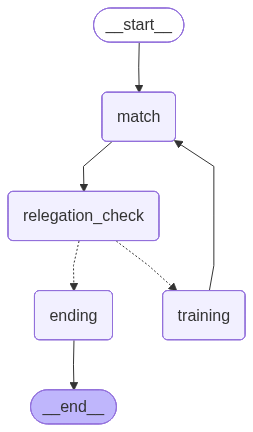

In [ ]:
graph

In [ ]:
# 전체 게임 테스트 (7라운드 자동 실행)
# halftime_choice / press_choice / training_input 은 Streamlit에서 위젯으로 대체 예정

init_state: LangGraphState = {
    "messages": [],
    "gs": GameState(),
    "current_phase": "match",
    "halftime_choice": "동기부여",
    "press_choice": "신중하게",
    "training_input": {"recovery": 34, "fitness": 33, "tactical": 33},
}

print("=== 토트넘 강등 저지 게임 시작 ===\n")
final_state = graph.invoke(init_state, {"recursion_limit": 60})

print("\n최종 매치 기록:")
for h in final_state["gs"].match_history:
    print(f"  {h}")

=== 토트넘 강등 저지 게임 시작 ===

[R32] vs Sunderland  1-2 (loss) | 승점:37  컨디션:59
  하프타임(동기부여): 우리는 지금 최선을 다하고 있다. 후반전, 한 골만 더 내면 된다. 포기
  경기후 스피치: 여러분, 오늘 경기는 아쉽습니다. Sunderland와의 경기를 잃었지만, 아직 포기할 때가 아닙니다. 우리...
  기자회견(신중하게): 감독이 신중하게 발언했지만, 연속된 패배로 인해 팬과 언론의 신뢰가 감소하고 있어 더욱 강 | Δ컨디션:-3
  경쟁팀: Nottingh=35pt  West Ham=32pt  Leeds Un=33pt  Burnley=20pt  Wolves=17pt
  -> 안전선:50pt  잔류확정:False  강등확정:False  잔여:6경기
  훈련(회복:34 체력:33 전술:33): 훈련 비중이 균형 잡혀 있어 적절합니다. 회복, 체력, 전술 모두 동일한 비중을 가지고 있 | Δ컨디션:+0  → 현재:59
[R33] vs Brighton  3-0 (win) | 승점:40  컨디션:56
  하프타임(동기부여): 우리는 지금 최선을 다하고 있다. 후반전, 한 골만 더 내면 된다. 포기
  경기후 스피치: 여러분, 방금 브라이튼과의 경기에서 승리한 것에 정말 자랑스럽습니다. 현재 승점 40점, 잔여 5경기를 남겨...
  기자회견(신중하게): The team has just won, and with 5 games remaining, | Δ컨디션:+2
  경쟁팀: Nottingh=38pt  West Ham=32pt  Leeds Un=33pt  Burnley=23pt  Wolves=17pt
  -> 안전선:47pt  잔류확정:False  강등확정:False  잔여:5경기


KeyboardInterrupt: 